In [1]:
%load_ext autoreload
%autoreload 2

In [60]:
import spacy
import glob
from constants import BASE_PATH
import json
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import text_cleaning as tc
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import itertools

In [47]:
tqdm.pandas()

In [95]:
from sklearn.feature_extraction.text import CountVectorizer

In [3]:
from constants import (
    JIBARO_WORDS, GIBARO_WORDS, CAMPESINO_WORDS, 
    LCCN_TO_NAME, BASE_PATH
)

In [37]:
nlp = spacy.blank("es")

In [29]:
target_df = pd.read_pickle('prelim_analysis_target_records_df.pkl')

In [30]:
texts = []
cleaned_texts = []
for idx, r in target_df.iterrows():
    with open(f"{BASE_PATH}/{r['lccn']}/{r['year']}/{r['month']}/{r['day']}/{r['edition']}/{r['sequence']}/cleaned.json") as f:
        d = json.load(f)
        texts.append(list(zip(d['text_blocks_raw'], d['text_blocks_cleaned'])))

In [31]:
target_df['texts'] = texts

In [32]:
target_df = target_df.explode('texts')

In [34]:
target_df['text_raw'] = target_df['texts'].apply(lambda x: x[0]['text'])
target_df['text_cleaned'] = target_df['texts'].apply(lambda x: x[1]['text'])
target_df['text_id'] = target_df['texts'].apply(lambda x: x[0]['id'])
target_df['height'] = target_df['texts'].apply(lambda x: x[0]['height'])
target_df['width'] = target_df['texts'].apply(lambda x: x[0]['width'])
target_df['hpos'] = target_df['texts'].apply(lambda x: x[0]['hpos'])
target_df['vpos'] = target_df['texts'].apply(lambda x: x[0]['vpos'])

In [39]:
target_df['doc_cleaned'] = target_df['text_cleaned'].apply(lambda x: nlp(x))

In [45]:
def contains_search_word(doc, targets):
    return any(token.lower_ in targets for token in doc)



In [48]:
target_df['contains_search_word_jibar'] = target_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, JIBARO_WORDS))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1026296/1026296 [00:37<00:00, 27106.42it/s]


In [51]:
target_df['contains_search_word_gibar'] = target_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, GIBARO_WORDS))
target_df['contains_search_word_campesin'] = target_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, CAMPESINO_WORDS))


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1026296/1026296 [00:38<00:00, 26556.95it/s]


In [368]:
doc = jibar_docs.iloc[0]
targets = JIBARO_WORDS
n_window = 10
spans = []
# def get_surrounding_spans(doc, targets, n_window):
#     for tok in doc:
#         if tok.lower_ in targets:
#             spans.append(doc[max(0, tok.i - n_window): min(len(doc), tok.i + n_window)])
#     return spans


# def get_surrounding_spans_as_doc(doc, targets, n_window):
#     spans = get_surrounding_spans(doc, targets, n_window)
#     return spacy.tokens.Doc.from_docs([s.as_doc() for s in spans])


def get_surrounding_spans(doc, targets, n_window):
    """
    Returns a list[Span] of windows around target tokens.
    """
    n = len(doc)

    # collect (start, end) windows
    windows = []
    for tok in doc:
        if tok.lower_ in targets:
            start = tok.i - n_window
            if start < 0:
                start = 0
            end = tok.i + n_window
            if end > n:
                end = n
            windows.append((start, end))

    if not windows:
        return []

    return [doc[s:e] for s, e in windows]


def get_surrounding_spans_as_doc(doc, targets, n_window):
    """
    Returns a single Doc made by concatenating the extracted spans (preserves token attrs).
    """
    spans = get_surrounding_spans(doc, targets, n_window)
    if not spans:
        return Doc(doc.vocab, words=[])

    # from_docs preserves token attributes best; fewer spans (via merge) => faster
    return spacy.tokens.Doc.from_docs([span.as_doc() for span in spans])

In [353]:
target_df['surrounding_text_jibar'] = target_df['doc_cleaned'].progress_apply(lambda x: get_surrounding_spans_as_doc(x, JIBARO_WORDS, 20))

  3%|███▍                                                                                                 | 35329/1026296 [03:03<1:48:42, 151.93it/s]

In [335]:
max(0, tok.i - n_window), min(len(doc), tok.i + n_window)

(243, 253)

In [369]:
get_surrounding_spans_as_doc(jibar_docs.iloc[3], JIBARO_WORDS, 10)

han consegaido; pero que conste, qu
nutítros jíbaros que son autono
mistas do verdad, siguen 

In [481]:
jibar_docs_df = target_df.loc[target_df['contains_search_word_jibar']]

In [57]:
jibar_docs=target_df.loc[target_df['contains_search_word_jibar']]['doc_cleaned']

In [93]:
# Custom tokenizer function
def spacy_tokenizer(doc):
    # Lemmatize, lowercase, and remove stopwords/punctuation
    tokens = [
        token.lower_.strip()
        for token in doc
        if token.lower_.strip() not in nlp.Defaults.stop_words and
           token.lower_.strip() not in '.,;:!?()[]{}"\'`~@#$%^&*+=-_<>|\\' and
           # Remove non-alphabetic tokens, and single-character tokens (optional)
           token.is_alpha and len(token.lower_.strip()) > 1
    ]
    return tokens

In [178]:
vectorizer = CountVectorizer(tokenizer=spacy_tokenizer, lowercase=False, ngram_range=(1, 2), min_df=2)
tf_matrix = vectorizer.fit_transform(jibar_docs.values).toarray()

/Users/weerasinghej/.local/share/virtualenvs/newspaper_ocr-SprSEqx4/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [180]:
tok_to_idx = {t: i for i, t in enumerate(vectorizer.get_feature_names_out())}

In [181]:
tok_to_idx['correos antillas']

10966

In [417]:
idxs = np.argwhere(
    (tf_matrix[:, tok_to_idx['san']] > 0) & 
    (tf_matrix[:, tok_to_idx['jíbara']] > 0) 
    # & 
    # (
    #     (tf_matrix[:, tok_to_idx['retorno']] > 0)
    #     & (tf_matrix[:, tok_to_idx['ida']] > 0)
    #     # & (tf_matrix[:, tok_to_idx['correos']] > 0)
    # ) | 
    # (
    #     (tf_matrix[:, tok_to_idx['retorno']] > 0)
    #     # & (tf_matrix[:, tok_to_idx['ida']] > 0)
    #     & (tf_matrix[:, tok_to_idx['correos']] > 0)
    # ) | 
    # (
    #     # (tf_matrix[:, tok_to_idx['retorno']] > 0)
    #     (tf_matrix[:, tok_to_idx['ida']] > 0)
    #     & (tf_matrix[:, tok_to_idx['correos']] > 0)
    # )
)
idxs

array([[  35],
       [  36],
       [ 642],
       [ 725],
       [ 756],
       [ 772],
       [ 831],
       [ 858],
       [ 950],
       [ 962],
       [ 998],
       [1069],
       [1095],
       [1157],
       [1222],
       [1370],
       [1473],
       [1559],
       [1566],
       [1725],
       [1777],
       [1861],
       [1907],
       [2096],
       [2236],
       [2379],
       [2707],
       [2740],
       [2780],
       [2816],
       [2823]])

In [184]:
idxs.flatten()

array([ 908,  978, 1020, 1093, 1461, 1464, 1466, 1487, 1990, 2541, 2562])

In [195]:
responses = []

In [319]:
jibar_docs.apply(lambda d: contains_search_word(d, 'juan')).mean()

np.float64(0.7469026548672566)

In [450]:
# filter_c = (
#     (pred_y > 0.0) & (pred_y < 0.3) & jibar_docs.apply(lambda d: contains_search_word(d, 'juan'))
# )
# for i in np.random.choice(np.argwhere(filter_c).flatten(), 10):
# for i in np.random.choice(idxs.flatten(), 10):
for i in idxs.flatten():
    print(jibar_docs.index[i])
    # print(jibar_docs.iloc[i])
    print(get_surrounding_spans_as_doc(jibar_docs.iloc[i], JIBARO_WORDS, 20))
    label = input("Label")
    if label == '-':
        continue
    responses.append((i, label))

AttributeError: 'list' object has no attribute 'flatten'

In [479]:
jibar_docs

link
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-03/ed-1/seq-2/    (creído, ver, algo, con, que, jamás, soñaron, ...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-05/ed-1/seq-4/    (Sabana, voluntaría, ......, 3, \n, ", Jibara,...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-02/ed-1/seq-4/    ((, la, Habana, ,, naevílas, ,, Jibara, y, Bar...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-20/ed-1/seq-2/    (cuando, creemos, que, nadie, había, \n, de, p...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-20/ed-1/seq-2/    (secunoart, io, esünwa, fsa, libe-at, que, com...
                                                                                                   ...                        
https://chroniclingamerica.loc.gov/lccn/sn88073003/1918-11-02/ed-1/seq-5/    (|, \n, Girls, ,, Learm, Shorthand, ;, \n, |, ...
https://chroniclingamerica.loc.gov/lccn/sn88073003/1918-11-02/ed-1/seq-2/    (El, sol, era, un, derroche, 

In [482]:
responses

[(np.int64(908), '0'),
 (np.int64(978), '1'),
 (np.int64(1020), '0'),
 (np.int64(1093), '0'),
 (np.int64(1461), '1'),
 (np.int64(1464), '1'),
 (np.int64(1466), '0'),
 (np.int64(1487), '1'),
 (np.int64(1990), '0'),
 (np.int64(2541), '0'),
 (np.int64(2562), '1'),
 (np.int64(2), '1'),
 (np.int64(13), '1'),
 (np.int64(29), '1'),
 (np.int64(38), '1'),
 (np.int64(40), '1'),
 (np.int64(43), '1'),
 (np.int64(44), '1'),
 (np.int64(45), '1'),
 (np.int64(49), '1'),
 (np.int64(57), '1'),
 (np.int64(63), '1'),
 (np.int64(72), '1'),
 (np.int64(74), '1'),
 (np.int64(75), '1'),
 (np.int64(80), '1'),
 (np.int64(81), '1'),
 (np.int64(84), '1'),
 (np.int64(88), '1'),
 (np.int64(89), '1'),
 (np.int64(90), '1'),
 (np.int64(103), '1'),
 (np.int64(109), '1'),
 (np.int64(118), '1'),
 (np.int64(119), '1'),
 (np.int64(122), '1'),
 (np.int64(126), '1'),
 (np.int64(128), '1'),
 (np.int64(129), '1'),
 (np.int64(133), '1'),
 (np.int64(134), '1'),
 (np.int64(143), '1'),
 (np.int64(144), '1'),
 (np.int64(146), '1'),


In [483]:
labels_data = []
for i, r in responses:
    labels_data.append({
        'link': jibar_docs.index[i],
        'text_id': jibar_docs_df.iloc[i]['text_id'],
        'label': int(r)
    })
labels_data_df = pd.DataFrame.from_dict(labels_data)

In [484]:
labels_data_df

,link,text_id,label
0,https://chroniclingamerica.loc.gov/lccn/sn9109...,P3_TB00001,0
1,https://chroniclingamerica.loc.gov/lccn/sn9109...,P4_TB00001,1
2,https://chroniclingamerica.loc.gov/lccn/sn9109...,P3_TB00008,0
3,https://chroniclingamerica.loc.gov/lccn/sn9109...,P3_TB00007,0
4,https://chroniclingamerica.loc.gov/lccn/sn9109...,P4_TB00003,1
...,...,...,...
220,https://chroniclingamerica.loc.gov/lccn/sn8807...,P1_TB00025,0
221,https://chroniclingamerica.loc.gov/lccn/sn8807...,P4_TB00016,1
222,https://chroniclingamerica.loc.gov/lccn/sn8807...,P4_TB00008,0
223,https://chroniclingamerica.loc.gov/lccn/sn8807...,P2_TB00015,1


In [485]:
labels_data_df.to_pickle('jibaro_classification_labels_df.pkl')

In [419]:
with open("jibaro_classification_labels.pkl", 'wb') as f:
    pickle.dump(responses, f)

In [451]:
idxs = [int(r[0]) for r in responses]
y = [int(r[1]) for r in responses]
X = tf_matrix[idxs,:]

jibar_docs_surrounding = jibar_docs.iloc[idxs].apply(lambda x: get_surrounding_spans_as_doc(x, JIBARO_WORDS, 40))
vectorizer2 = CountVectorizer(tokenizer=spacy_tokenizer, lowercase=False, ngram_range=(1, 2), min_df=2)
X2 = vectorizer2.fit_transform(jibar_docs_surrounding.values).toarray()

len(responses)


/Users/weerasinghej/.local/share/virtualenvs/newspaper_ocr-SprSEqx4/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


225

In [248]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import make_scorer, f1_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_validate

In [452]:

base_svm = LinearSVC(
    C=1.0,
    # class_weight="auto",
    random_state=42,
    max_iter=20000
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",   # Platt scaling
    cv=5,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = cross_validate(
    calibrated_svm,
    # X=X,
    X=X2,
    y=y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1,
)

print({k: np.mean(v) for k, v in results.items() if k.startswith("test_")})

{'test_accuracy': np.float64(0.9022222222222223), 'test_precision': np.float64(0.910865105908584), 'test_recall': np.float64(0.9103333333333333), 'test_f1': np.float64(0.9102992345874521), 'test_roc_auc': np.float64(0.9477619047619047)}


In [446]:
np.mean(y)

np.float64(0.5466666666666666)

In [453]:
calibrated_svm.fit(X2, y)

,estimator,LinearSVC(max...ndom_state=42)
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


In [454]:
pred_y = calibrated_svm.predict_proba(tf_matrix)[:, 1]

In [ ]:
np.argwhere((pred_y > 0.3) & (pred_y < 0.6)).flatten()

(array([67., 26., 10.,  0.,  0.,  0.,  2.,  5., 47., 68.]),
 array([3.00314445e-04, 9.98401943e-02, 1.99380074e-01, 2.98919954e-01,
        3.98459834e-01, 4.97999714e-01, 5.97539594e-01, 6.97079474e-01,
        7.96619354e-01, 8.96159234e-01, 9.95699113e-01]),
 <BarContainer object of 10 artists>)

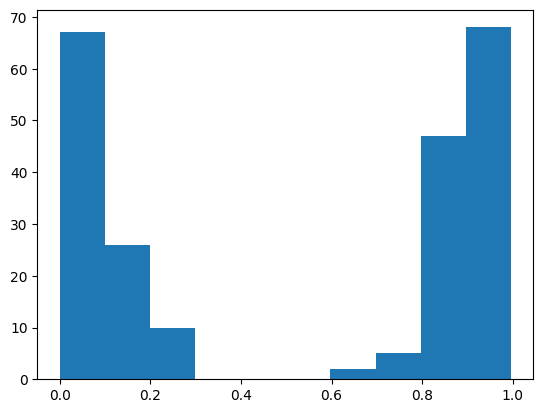

In [455]:
plt.hist(pred_y)

In [427]:
pos_idxs = np.argwhere(pred_y == 1).flatten()

In [428]:
jibar_docs[pred_y < 0.5]

link
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-03/ed-1/seq-2/    (creído, ver, algo, con, que, jamás, soñaron, ...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-20/ed-1/seq-2/    (cuando, creemos, que, nadie, había, \n, de, p...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-20/ed-1/seq-2/    (secunoart, io, esünwa, fsa, libe-at, que, com...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-27/ed-1/seq-3/    (Al, hacer, la, explosión, ,, un, jíbaro, que, ;)
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-29/ed-1/seq-3/    (Kpecia'ista, en, la, curación, de, \n, las, e...
                                                                                                   ...                        
https://chroniclingamerica.loc.gov/lccn/sn88073003/1918-11-02/ed-1/seq-5/    (|, \n, Girls, ,, Learm, Shorthand, ;, \n, |, ...
https://chroniclingamerica.loc.gov/lccn/sn88073003/1918-11-02/ed-1/seq-2/    (El, sol, era, un, derroche, 

In [316]:
len(responses)

167

In [429]:
len(jibar_docs)

2825

In [264]:
jibar_docs[pos_idxs]

/var/folders/nw/4k8cbbj93j9gvknkvl_w8c1c0000gq/T/ipykernel_57738/971559592.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  jibar_docs[pos_idxs]


Series([], Name: doc_cleaned, dtype: object)

In [68]:
def get_term_freqs(docs):
    tf = defaultdict(int)
    for t in itertools.chain.from_iterable(docs):
        t = t.lower_
        # Remove spanish stop words and punctuation
        if t in nlp.Defaults.stop_words or t in '.,;:!?()[]{}"\'`~@#$%^&*+=-_<>|\\' or len(t) < 2:
            continue
        tf[t] += 1
    return {'tf': dict(tf)}


In [466]:
selected_docs = jibar_docs_surrounding[np.array(y) < 0.5]#jibar_docs[pred_y < 0.1].copy()

In [467]:
len(selected_docs)

102

In [468]:
# tfs = get_term_freqs(selected_docs.apply(lambda x: get_surrounding_spans_as_doc(x, JIBARO_WORDS, 20)))
tfs = get_term_freqs(selected_docs)

In [469]:
sorted(tfs['tf'].items(), key=lambda item: -item[1])

[('jíbara', 59),
 ('jíbaro', 40),
 ('jibaro', 39),
 ('...', 39),
 ('fué', 28),
 ('jíbaros', 26),
 ('don', 24),
 ('san', 20),
 ('noche', 18),
 ('caballeros', 16),
 ('casa', 15),
 ('juan', 15),
 ('periódico', 13),
 ('do', 12),
 ('obra', 12),
 ('fiesta', 12),
 ('so', 11),
 ('ia', 11),
 ('ta', 11),
 ('damas', 11),
 ('colón', 11),
 ('bailes', 11),
 ('titulada', 11),
 ('campos', 11),
 ('rico', 10),
 ('cuba', 10),
 ('manuel', 10),
 ('trajes', 10),
 ('metros', 10),
 ('jibara', 10),
 ('eu', 9),
 ('corrientes', 9),
 ('celebrará', 9),
 ('consejo', 9),
 ('1543', 9),
 ('tradicional', 9),
 ('canciones', 9),
 ('obsequios', 9),
 ('apropiados', 9),
 ('ofrecerán', 9),
 ('con-', 9),
 ('currentes', 9),
 ('vestirán', 9),
 ('típicos', 9),
 ('ádeb', 9),
 ('pablo', 8),
 ('puerto', 8),
 ('ios', 8),
 ('amores', 8),
 ('sargento', 8),
 ('droz', 8),
 ('josé', 7),
 ('caballos', 7),
 ('cosa', 7),
 ('carrera', 7),
 ('cayey', 7),
 ('playa', 7),
 ('gui', 7),
 ('casado', 7),
 ('barrio', 6),
 ('fen', 6),
 ('recibe', 6),


In [ ]:
(jibar --> Gibar
